# Create file storing gbn shares at the ISCO level (weighted/unweighted by employment shares)
Felix Zaussinger | 02.09.2022

**Core Analysis Goal(s)**
1. Create two sets of shares at the ISCO-level:
    - weighted by KldB employment shares
    - unweighted mean based on ESCO-level classification
2. Compare results

**Key Insight(s)**
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("poster")
sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

#### Prepare unweighted shares at ISCO-08 3-digit level

Read final GBN classifications (ESCO-level)

In [2]:
df_sl = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists.csv"),
    index_col=0
)

df_sl_tobi = pd.read_csv(
    os.path.join(useful_paths.data_processed, "esco", "esco_level_gbn_classification_short_lists_tobi.csv"),
    index_col=0
)

Create ESCO-ISCO correspondance file

In [3]:
from src.data.framework import Esco
esco = Esco()
occ = esco.occupations
isco_col = "isco_code"
data_container = []

In [4]:
for n_digits_isco in [1, 2, 3, 4]:
    # Create ESCO-ISCO correspondance file
    occ[isco_col] = occ.iscoGroup.str[:n_digits_isco]
    esco_to_isco = pd.merge(occ, esco.isco_groups[["code", "preferredLabel"]], left_on=isco_col, right_on="code", how="left", suffixes=["_esco", "_isco"])
    esco_to_isco = esco_to_isco[["conceptUri", isco_col, "preferredLabel_isco"]]

    # Merge ISCO codes, calculate per-category count of ESCO occupations within ISCO groups
    df_sl_merged = df_sl.merge(esco_to_isco, on="conceptUri", how="left")
    df_sl_tobi_merged = df_sl_tobi.merge(esco_to_isco, on="conceptUri", how="left")

    df_sl_merged["n_esco"] = 1
    df_sl_merged_by_isco = df_sl_merged.groupby([isco_col, "preferredLabel_isco", "gbn_classification_short_list"])["n_esco"].count()
    df_sl_merged_by_isco = df_sl_merged_by_isco.reset_index()
    df_sl_merged_by_isco["isco_level"] = n_digits_isco

    df_sl_tobi_merged["n_esco"] = 1
    df_sl_tobi_merged_by_isco = df_sl_tobi_merged.groupby([isco_col, "preferredLabel_isco", "gbn_classification_short_list"])["n_esco"].count()
    df_sl_tobi_merged_by_isco = df_sl_tobi_merged_by_isco.reset_index()
    df_sl_tobi_merged_by_isco["isco_level"] = n_digits_isco

    # Calc unweighted shares at ISCO-08 3-digit level: df_sl
    cnt = 0
    data_store = []
    cols_all = {"green", "brown", "neutral"}

    for grp, grp_df in df_sl_merged_by_isco.groupby(isco_col):

        # pivot long to wide, simplify multi-indices
        grp_df_piv = grp_df.pivot(index=["isco_level", isco_col, "preferredLabel_isco"], columns=["gbn_classification_short_list"], values=["n_esco"])
        grp_df_piv.columns = grp_df_piv.columns.get_level_values(1)
        grp_df_piv = grp_df_piv.reset_index()
        #grp_df_piv.index = grp_df_piv.index.get_level_values(0)

        # create missing column
        cols_exist = set(grp_df_piv.columns.tolist())
        col_missing = list(cols_all - cols_exist)
        grp_df_piv[col_missing] = 0

        # calc shares
        grp_df_piv["N"] = grp_df_piv[list(cols_all)].sum(axis=1)

        for col in list(cols_all):
            grp_df_piv["share_{}".format(col)] = grp_df_piv[col] / grp_df_piv["N"]

        # append
        data_store.append(grp_df_piv)

        # concat to new df
        df_out = pd.concat(data_store)

        # save individual file
        df_out.to_csv(
            os.path.join(useful_paths.data_processed, "esco", "short_list_gbn_shares_by_isco{}d_unweighted.csv".format(n_digits_isco))
        )

        # flag list version
        df_out["list_version"] = "short_list"

        # global append
        data_container.append(df_out)

    # Calc unweighted shares at ISCO-08 3-digit level: df_sl_tobi
    cnt = 0
    data_store = []
    cols_all = {"green", "brown", "neutral"}

    for grp, grp_df in df_sl_tobi_merged_by_isco.groupby(isco_col):

        # pivot long to wide, simplify multi-indices
        grp_df_piv = grp_df.pivot(index=["isco_level", isco_col, "preferredLabel_isco"], columns=["gbn_classification_short_list"], values=["n_esco"])
        grp_df_piv.columns = grp_df_piv.columns.get_level_values(1)
        grp_df_piv = grp_df_piv.reset_index()
        #grp_df_piv.index = grp_df_piv.index.get_level_values(0)

        # create missing column
        cols_exist = set(grp_df_piv.columns.tolist())
        col_missing = list(cols_all - cols_exist)
        grp_df_piv[col_missing] = 0

        # calc shares
        grp_df_piv["N"] = grp_df_piv[list(cols_all)].sum(axis=1)

        for col in list(cols_all):
            grp_df_piv["share_{}".format(col)] = grp_df_piv[col] / grp_df_piv["N"]

        # append
        data_store.append(grp_df_piv)

    # concat to new df
    df_out = pd.concat(data_store)

    # save individual file
    df_out.to_csv(
        os.path.join(useful_paths.data_processed, "esco", "short_list_tobi_gbn_shares_by_isco{}d_unweighted.csv".format(n_digits_isco))
    )

    # flag list version
    df_out["list_version"] = "short_list_tobi"

    # global append
    data_container.append(df_out)

Combine to single long DF and save (more compact than single csvs)

In [5]:
gbn_shares_final = pd.concat(data_container).drop_duplicates()
gbn_shares_final = gbn_shares_final.sort_values(["list_version", "isco_level"], ascending=True)
gbn_shares_final = gbn_shares_final.reset_index(drop=True)

utils.save_df_to_files(
    df=gbn_shares_final,
    output_dir=os.path.join(useful_paths.data_processed, "esco"),
    fname_no_ext="final_gbn_shares_by_isco_unweighted"
)

In [6]:
gbn_shares_final

gbn_classification_short_list,isco_level,isco_code,preferredLabel_isco,neutral,green,brown,N,share_neutral,share_green,share_brown,list_version
0,1,0,Armed forces occupations,21,0,0,21,1.000000,0.000000,0.000000,short_list
1,1,1,Managers,331,3,4,338,0.979290,0.008876,0.011834,short_list
2,1,2,Professionals,782,39,25,846,0.924350,0.046099,0.029551,short_list
3,1,3,Technicians and associate professionals,605,36,12,653,0.926493,0.055130,0.018377,short_list
4,1,4,Clerical support workers,87,0,2,89,0.977528,0.000000,0.022472,short_list
...,...,...,...,...,...,...,...,...,...,...,...
1201,4,9613,Sweepers and related labourers,1,0,0,1,1.000000,0.000000,0.000000,short_list_tobi
1202,4,9621,"Messengers, package deliverers and luggage por...",2,0,0,2,1.000000,0.000000,0.000000,short_list_tobi
1203,4,9622,Odd job persons,1,0,0,1,1.000000,0.000000,0.000000,short_list_tobi
1204,4,9623,Meter readers and vending-machine collectors,2,0,0,2,1.000000,0.000000,0.000000,short_list_tobi


#### Prepare weighted shares at ISCO-08 3-digit level (via KldB weights)

In [27]:
gbn_shares_wtd_3d_raw = pd.read_excel(
    os.path.join(useful_paths.project_dir, "rcode", "D_Ergebnisse", "_OUTPUT_FINAL_GEPRÜFT", "weighted_occ_shares_ISCO3D_geprüft.xlsx"),
    dtype={"EF541UG1": str}
)

# join isco names
gbn_shares_wtd_3d = gbn_shares_wtd_3d_raw.merge(
    right=esco.isco_groups[["conceptUri", "preferredLabel", "code"]], left_on="EF541UG1", right_on="code", how="left"
).rename(columns={"code": "isco_code"})

In [29]:
gbn_shares_wtd_3d

,EF541UG1,n_obs,EF952_sum,share_green_wtd,share_green_unwtd,share_brown_wtd,share_brown_unwtd,share_neutral_wtd,share_neutral_unwtd,conceptUri,preferredLabel,isco_code
0,011,105.0,12347.157,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C011,Commissioned armed forces officers,011
1,021,72.0,9550.961,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C021,Non-commissioned armed forces officers,021
2,031,1263.0,168173.179,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C031,"Armed forces occupations, other ranks",031
3,111,383.0,40370.029,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C111,Legislators and senior officials,111
4,112,6730.0,734645.324,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C112,Managing directors and chief executives,112
...,...,...,...,...,...,...,...,...,...,...,...,...
118,932,3351.0,383081.002,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C932,Manufacturing labourers,932
119,933,6395.0,742086.441,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C933,Transport and storage labourers,933
120,941,3264.0,385568.918,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C941,Food preparation assistants,941
121,961,510.0,57909.302,0.673845,0.673856,0.0,0.0,0.326155,0.326144,http://data.europa.eu/esco/isco/C961,Refuse workers,961


In [43]:
import pingouin as pg
gbn_shares_comp = gbn_shares_wtd_3d.merge(gbn_shares_final, on="isco_code", how="left")
gbn_shares_comp_sl = gbn_shares_comp.query("list_version == 'short_list'")
gbn_shares_comp_slt = gbn_shares_comp.query("list_version == 'short_list_tobi'")

In [51]:
gbn_shares_comp_sl

,EF541UG1,n_obs,EF952_sum,share_green_wtd,share_green_unwtd,share_brown_wtd,share_brown_unwtd,share_neutral_wtd,share_neutral_unwtd,conceptUri,preferredLabel,isco_code,isco_level,preferredLabel_isco,neutral,green,brown,N,share_neutral,share_green,share_brown,list_version
0,011,105.0,12347.157,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C011,Commissioned armed forces officers,011,3.0,Commissioned armed forces officers,12.0,0.0,0.0,12.0,1.00,0.00,0.0,short_list
2,021,72.0,9550.961,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C021,Non-commissioned armed forces officers,021,3.0,Non-commissioned armed forces officers,4.0,0.0,0.0,4.0,1.00,0.00,0.0,short_list
4,031,1263.0,168173.179,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C031,"Armed forces occupations, other ranks",031,3.0,"Armed forces occupations, other ranks",5.0,0.0,0.0,5.0,1.00,0.00,0.0,short_list
6,111,383.0,40370.029,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C111,Legislators and senior officials,111,3.0,Legislators and senior officials,17.0,0.0,0.0,17.0,1.00,0.00,0.0,short_list
8,112,6730.0,734645.324,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C112,Managing directors and chief executives,112,3.0,Managing directors and chief executives,8.0,0.0,0.0,8.0,1.00,0.00,0.0,short_list
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,932,3351.0,383081.002,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C932,Manufacturing labourers,932,3.0,Manufacturing labourers,4.0,0.0,0.0,4.0,1.00,0.00,0.0,short_list
237,933,6395.0,742086.441,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C933,Transport and storage labourers,933,3.0,Transport and storage labourers,12.0,0.0,0.0,12.0,1.00,0.00,0.0,short_list
239,941,3264.0,385568.918,0.000000,0.000000,0.0,0.0,1.000000,1.000000,http://data.europa.eu/esco/isco/C941,Food preparation assistants,941,3.0,Food preparation assistants,4.0,0.0,0.0,4.0,1.00,0.00,0.0,short_list
241,961,510.0,57909.302,0.673845,0.673856,0.0,0.0,0.326155,0.326144,http://data.europa.eu/esco/isco/C961,Refuse workers,961,3.0,Refuse workers,1.0,3.0,0.0,4.0,0.25,0.75,0.0,short_list


<AxesSubplot:xlabel='share_green', ylabel='share_green_wtd'>

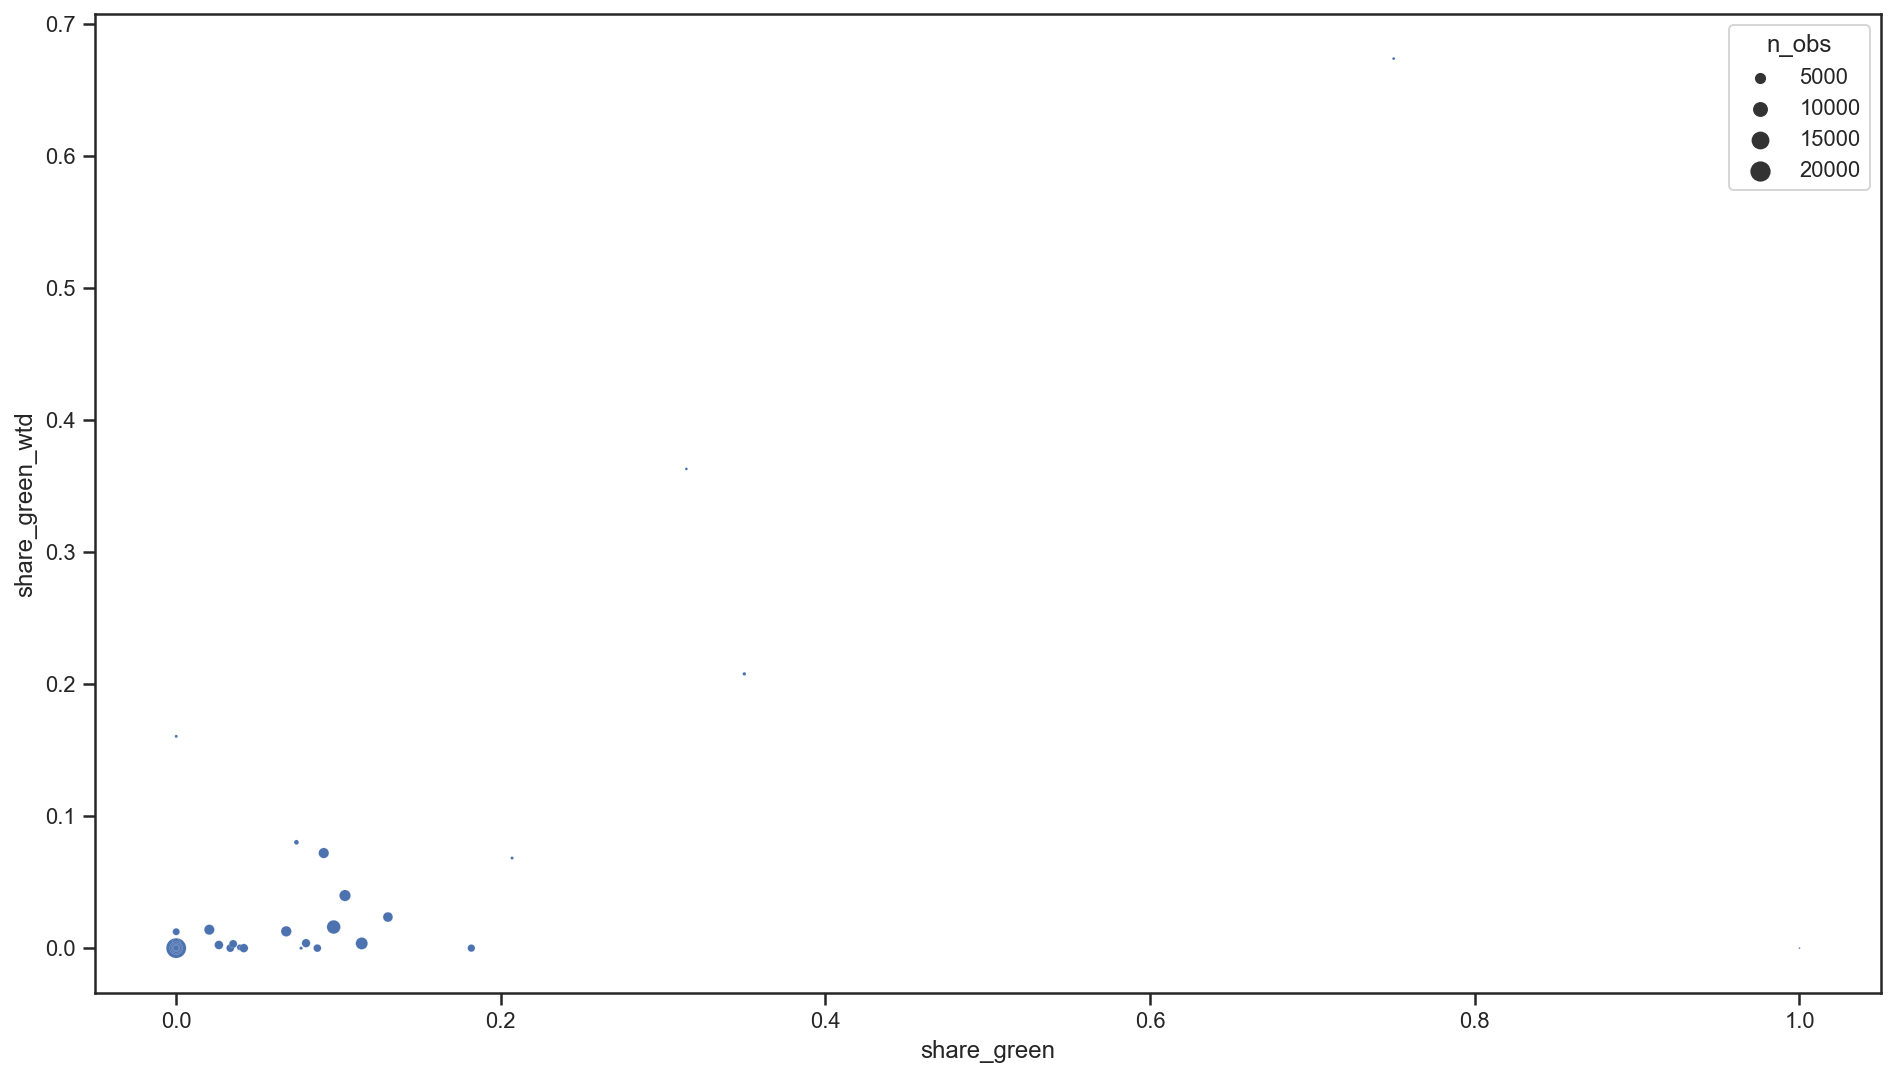

In [65]:
sns.scatterplot(data=gbn_shares_comp_sl, x="share_green", y="share_green_wtd", size="n_obs", sizes=(0, 100))

In [44]:
gbn_shares_comp_sl.iloc[:, gbn_shares_comp_sl.columns.str.startswith("share")].rcorr()

,share_green_wtd,share_green_unwtd,share_brown_wtd,share_brown_unwtd,share_neutral_wtd,share_neutral_unwtd,share_neutral,share_green,share_brown
share_green_wtd,-,***,,,***,***,**,***,
share_green_unwtd,1.0,-,,,***,***,**,***,
share_brown_wtd,0.09,0.09,-,***,***,***,***,,***
share_brown_unwtd,0.088,0.088,1.0,-,***,***,***,,***
share_neutral_wtd,-0.917,-0.917,-0.48,-0.479,-,***,***,***,**
share_neutral_unwtd,-0.915,-0.915,-0.483,-0.482,1.0,-,***,***,**
share_neutral,-0.277,-0.276,-0.541,-0.539,0.46,0.46,-,***,***
share_green,0.465,0.464,0.052,0.051,-0.431,-0.429,-0.582,-,
share_brown,-0.003,-0.003,0.626,0.624,-0.248,-0.249,-0.8,-0.022,-


In [45]:
gbn_shares_comp_slt.iloc[:, gbn_shares_comp_slt.columns.str.startswith("share")].rcorr()

,share_green_wtd,share_green_unwtd,share_brown_wtd,share_brown_unwtd,share_neutral_wtd,share_neutral_unwtd,share_neutral,share_green,share_brown
share_green_wtd,-,***,,,***,***,***,***,
share_green_unwtd,1.0,-,,,***,***,***,***,
share_brown_wtd,0.09,0.09,-,***,***,***,***,,***
share_brown_unwtd,0.088,0.088,1.0,-,***,***,***,,***
share_neutral_wtd,-0.917,-0.917,-0.48,-0.479,-,***,***,***,***
share_neutral_unwtd,-0.915,-0.915,-0.483,-0.482,1.0,-,***,***,***
share_neutral,-0.453,-0.452,-0.431,-0.431,0.572,0.572,-,***,***
share_green,0.465,0.464,0.052,0.051,-0.431,-0.429,-0.91,-,
share_brown,0.101,0.101,0.929,0.929,-0.462,-0.464,-0.471,0.064,-
